# EDA giao dịch bất thường và CustomerID thiếu

Notebook nghiên cứu hồi cứu, không phải detector sản xuất. **Thiếu định danh không đồng nghĩa giao dịch sai.** Giữ tất cả dòng đầu vào, không điền CustomerID, không ghi dữ liệu. Quan sát được tách khỏi suy luận nghiệp vụ; không có nhãn xác thực để đo precision/recall.

## A. Nguồn dữ liệu, schema và đối chiếu
Chạy từ root repo hoặc thư mục `notebooks`. PyArrow đọc Parquet theo schema do PySpark ghi; pandas chỉ phục vụ thống kê và biểu đồ. CSV dùng ISO-8859-1 như EDA gốc. Khác biệt encoding/parser được báo cáo, không tự sửa.

In [1]:
from pathlib import Path
from datetime import datetime, timezone
import hashlib, platform, ast
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
pd.set_option('display.max_columns', 16)
pd.set_option('display.max_rows', 60)
plt.rcParams.update({'figure.figsize': (11, 4), 'font.size': 10})
ROOT = next((p for p in [Path.cwd(), Path.cwd().parent] if (p/'scripts/pyspark_clean.py').is_file()), None)
if ROOT is None: raise FileNotFoundError('Chạy notebook từ root repo hoặc notebooks.')
CSV = ROOT/'data/raw/data.csv'
PARQUET = ROOT/'data/audit/anomalies.parquet'
if not CSV.is_file() or not PARQUET.is_dir(): raise FileNotFoundError('Thiếu CSV hoặc anomalies.parquet; không tự tạo lại dữ liệu.')
def fingerprints():
    files = [CSV] + sorted(p for p in PARQUET.rglob('*') if p.is_file())
    rows = []
    for path in files:
        digest = hashlib.sha256()
        with path.open('rb') as f:
            for block in iter(lambda: f.read(1024*1024), b''): digest.update(block)
        rows.append({'file': str(path.relative_to(ROOT)), 'bytes': path.stat().st_size, 'sha256': digest.hexdigest()})
    return pd.DataFrame(rows)
before = fingerprints()
display(pd.Series({'run_utc': datetime.now(timezone.utc).isoformat(), 'python': platform.python_version(), 'pandas': pd.__version__, 'numpy': np.__version__, 'pyarrow': pa.__version__, 'matplotlib': matplotlib.__version__}))
with pd.option_context('display.max_rows', None, 'display.max_colwidth', 100): display(before)
arrow_table = pq.read_table(PARQUET)
print('Schema Parquet từ PyArrow:'); print(arrow_table.schema)
original = arrow_table.to_pandas()
COLS = original.columns.tolist()
raw = pd.read_csv(CSV, encoding='ISO-8859-1', dtype={'CustomerID':'string','InvoiceNo':'string','Quantity':'int64','UnitPrice':'float64'}, parse_dates=['InvoiceDate'], date_format='%m/%d/%Y %H:%M')
TEXT = ['InvoiceNo','StockCode','Description','CustomerID','Country']
def canonical(frame):
    out = frame[COLS].copy()
    for c in TEXT: out[c] = out[c].astype('string')
    out['Quantity'] = pd.to_numeric(out['Quantity'], errors='coerce').astype('Int64')
    out['UnitPrice'] = pd.to_numeric(out['UnitPrice'], errors='coerce').astype('float64')
    out['InvoiceDate'] = pd.to_datetime(out['InvoiceDate'], errors='coerce').astype('datetime64[ns]')
    return out
raw_c = canonical(raw)
df = canonical(original)
dedup = raw_c.drop_duplicates()
def missing(s): return s.isna() | s.astype('string').str.strip().eq('').fillna(False)
summary = []
for name, frame in [('CSV gốc',raw_c),('CSV loại trùng',dedup),('Parquet',df)]:
    summary.append({'nguon':name,'dong':len(frame),'hoa_don':frame.InvoiceNo.nunique(),'san_pham':frame.StockCode.nunique(),'ID_null':int(frame.CustomerID.isna().sum()),'ID_thieu_ke_ca_rong':int(missing(frame.CustomerID).sum()),'ID_thieu_pct':100*missing(frame.CustomerID).mean(),'trung':int(frame.duplicated().sum()),'tu':frame.InvoiceDate.min(),'den':frame.InvoiceDate.max()})
display(pd.DataFrame(summary))
# So sánh đa tập chính xác theo đủ 8 cột, không dựa riêng vào hash dòng.
left = dedup.groupby(COLS, dropna=False).size().rename('csv_count')
right = df.groupby(COLS, dropna=False).size().rename('parquet_count')
comparison = pd.concat([left,right],axis=1).fillna(0)
mismatch = comparison[comparison.csv_count.ne(comparison.parquet_count)]
print('Số tổ hợp dòng khác nhau:',len(mismatch))
display(mismatch.reset_index().head(10))
# Kiểm tra đa tập trên 7 cột còn lại; tránh join nhiều-nhiều để giải thích chênh lệch.
non_description=[c for c in COLS if c!='Description']
seven=pd.concat([dedup.groupby(non_description,dropna=False).size().rename('csv'),df.groupby(non_description,dropna=False).size().rename('parquet')],axis=1).fillna(0)
seven_mismatch=int(seven.csv.ne(seven.parquet).sum())
print('Tổ hợp khác nhau khi bỏ riêng Description:',seven_mismatch)
unique_csv=dedup.loc[~dedup.duplicated(non_description,keep=False)]
unique_parquet=df.loc[~df.duplicated(non_description,keep=False)]
paired=unique_csv.merge(unique_parquet,on=non_description,suffixes=('_csv','_parquet'),validate='one_to_one')
desc_diff=paired.loc[paired.Description_csv.fillna('<NULL>').ne(paired.Description_parquet.fillna('<NULL>'))]
print('Ví dụ khác Description trên khóa 7 cột duy nhất (không fanout):')
display(desc_diff[['InvoiceNo','StockCode','Description_csv','Description_parquet']].head(10))

quality = pd.DataFrame({'dtype':df.dtypes.astype(str),'null':df.isna().sum(),'rong':{c:int(df[c].astype('string').str.strip().eq('').fillna(False).sum()) for c in COLS}})
quality['so_khong_huu_han'] = 0
for c in ['Quantity','UnitPrice']: quality.loc[c,'so_khong_huu_han'] = int((df[c].notna() & ~np.isfinite(df[c].astype(float))).sum())
display(quality)
N = len(df)
assert N > 0


run_utc       2026-09-23T02:49:51.851536+00:00
python                                  3.14.5
pandas                                   3.0.3
numpy                                    2.4.6
pyarrow                                 25.0.0
matplotlib                              3.11.0
dtype: str

,file,bytes,sha256
0,data\raw\data.csv,45580638,d07aec9960083af2339975a3f9d3b26313b342dcd9f86cce0b919b1cde639a44
1,data\audit\anomalies.parquet\._SUCCESS.crc,8,1d44f510ec2ed7595badbec80583316defc14e8dd89130d719724149adfaa07d
2,data\audit\anomalies.parquet\.part-00000-4c0245f7-e228-451d-86c3-6093b0c8ccf2-c000.snappy.parque...,5072,138ae16de3e0f66683ec976ba20f1ae38de4d33967108099666854b0e20968fb
3,data\audit\anomalies.parquet\.part-00001-4c0245f7-e228-451d-86c3-6093b0c8ccf2-c000.snappy.parque...,5076,826d271f30049b058d679de1bd62a24f031bdbcf5f04b5be958771ebc39e961b
4,data\audit\anomalies.parquet\.part-00002-4c0245f7-e228-451d-86c3-6093b0c8ccf2-c000.snappy.parque...,5092,d334af23cfa67aa1213e4017781365a45cf8c49606bf9b178c255e4ebdd84e32
5,data\audit\anomalies.parquet\.part-00003-4c0245f7-e228-451d-86c3-6093b0c8ccf2-c000.snappy.parque...,5076,aa7d9835d33f78a3a6a47e9f630e68643089c6d0e9336a3a442f7ec7bc23d466
6,data\audit\anomalies.parquet\.part-00004-4c0245f7-e228-451d-86c3-6093b0c8ccf2-c000.snappy.parque...,5080,5154243397d988b584d577e1fa5a2649e9c23776b203e5d69e5047a8deb1fab9
7,data\audit\anomalies.parquet\.part-00005-4c0245f7-e228-451d-86c3-6093b0c8ccf2-c000.snappy.parque...,5068,3322215e564a32214e9b875b3160d912b81652a2f8338b2d95a934ce5b4dbf5a
8,data\audit\anomalies.parquet\.part-00006-4c0245f7-e228-451d-86c3-6093b0c8ccf2-c000.snappy.parque...,5088,38920c842afbc685ddadd52d71ca1b1bd1184c855373d693a1d7c94b14951ebe
9,data\audit\anomalies.parquet\.part-00007-4c0245f7-e228-451d-86c3-6093b0c8ccf2-c000.snappy.parque...,5064,7385b97269d115c684f112e337ce57c6fccd238a3e7c0211f02ae8316d9610dd


Schema Parquet từ PyArrow:
InvoiceNo: string
StockCode: string
Description: string
Quantity: int32
InvoiceDate: timestamp[ns]
UnitPrice: double
CustomerID: string
Country: string
-- schema metadata --
org.apache.spark.version: '4.2.0'
org.apache.spark.sql.parquet.row.metadata: '{"type":"struct","fields":[{"' + 541


,nguon,dong,hoa_don,san_pham,ID_null,ID_thieu_ke_ca_rong,ID_thieu_pct,trung,tu,den
0,CSV gốc,541909,25900,4070,135080,135080,24.926694,5268,2010-12-01 08:26:00,2011-12-09 12:50:00
1,CSV loại trùng,536641,25900,4070,135037,135037,25.163377,0,2010-12-01 08:26:00,2011-12-09 12:50:00
2,Parquet,536641,25900,4070,135037,135037,25.163377,0,2010-12-01 08:26:00,2011-12-09 12:50:00


Số tổ hợp dòng khác nhau: 2540


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,csv_count,parquet_count
0,536477,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2010-12-01 12:27:00,2.10,16210,United Kingdom,1.0,0.0
1,536540,85071C,"CHARLIE+LOLA""EXTREMELY BUSY"" SIGN",6,2010-12-01 14:05:00,2.55,14911,EIRE,1.0,0.0
2,536544,90214D,"LETTER ""D"" BLING KEY RING",1,2010-12-01 14:32:00,0.85,<NA>,United Kingdom,1.0,0.0
3,536544,90214G,"LETTER ""G"" BLING KEY RING",1,2010-12-01 14:32:00,0.85,<NA>,United Kingdom,1.0,0.0
4,536544,90214H,"LETTER ""H"" BLING KEY RING",1,2010-12-01 14:32:00,0.85,<NA>,United Kingdom,1.0,0.0
5,536544,90214J,"LETTER ""J"" BLING KEY RING",1,2010-12-01 14:32:00,0.85,<NA>,United Kingdom,1.0,0.0
6,536544,90214R,"LETTER ""R"" BLING KEY RING",1,2010-12-01 14:32:00,0.85,<NA>,United Kingdom,1.0,0.0
7,536557,22041,"RECORD FRAME 7"" SINGLE SIZE",4,2010-12-01 14:41:00,2.55,17841,United Kingdom,1.0,0.0
8,536576,22041,"RECORD FRAME 7"" SINGLE SIZE",144,2010-12-01 16:11:00,2.10,13777,United Kingdom,1.0,0.0
9,536591,90214J,"LETTER ""J"" BLING KEY RING",2,2010-12-01 16:57:00,1.25,14606,United Kingdom,1.0,0.0


Tổ hợp khác nhau khi bỏ riêng Description: 0


Ví dụ khác Description trên khóa 7 cột duy nhất (không fanout):


,InvoiceNo,StockCode,Description_csv,Description_parquet
849,536477,22041,"RECORD FRAME 7"" SINGLE SIZE","""RECORD FRAME 7"""" SINGLE SIZE """
1370,536540,85071C,"CHARLIE+LOLA""EXTREMELY BUSY"" SIGN","""CHARLIE+LOLA""""EXTREMELY BUSY"""" SIGN"""
1773,536544,90214D,"LETTER ""D"" BLING KEY RING","""LETTER """"D"""" BLING KEY RING"""
1774,536544,90214G,"LETTER ""G"" BLING KEY RING","""LETTER """"G"""" BLING KEY RING"""
1775,536544,90214H,"LETTER ""H"" BLING KEY RING","""LETTER """"H"""" BLING KEY RING"""
1776,536544,90214J,"LETTER ""J"" BLING KEY RING","""LETTER """"J"""" BLING KEY RING"""
1777,536544,90214R,"LETTER ""R"" BLING KEY RING","""LETTER """"R"""" BLING KEY RING"""
2013,536557,22041,"RECORD FRAME 7"" SINGLE SIZE","""RECORD FRAME 7"""" SINGLE SIZE """
2265,536576,22041,"RECORD FRAME 7"" SINGLE SIZE","""RECORD FRAME 7"""" SINGLE SIZE """
2379,536591,90214M,"LETTER ""M"" BLING KEY RING","""LETTER """"M"""" BLING KEY RING"""


,dtype,null,rong,so_khong_huu_han
InvoiceNo,string,0,0,0
StockCode,string,0,0,0
Description,string,1454,0,0
Quantity,Int64,0,0,0
InvoiceDate,datetime64[ns],0,0,0
UnitPrice,float64,0,0,0
CustomerID,string,135037,0,0
Country,string,0,0,0


## B. Nhóm có/thiếu CustomerID
Mẫu số của các tỷ lệ là số dòng trong từng nhóm. Số hóa đơn giữa hai nhóm có thể giao nhau. Giá trị có dấu gồm hoàn/hủy và bút toán; giá trị dương chỉ mô tả các dòng Quantity và UnitPrice dương, chưa loại hết phí hay xác nhận doanh thu thuần.

,dong,hoa_don,huy_pct,qty_am_pct,gia_0_pct,gia_am_pct,gia_tri_co_dau,gia_tri_dong_duong
nhom,,,,,,,,
Có ID,401604,22190,2.209141,2.209141,0.009960,0.000000,8278519.424,8887208.894
Thiếu ID,135037,3710,0.280664,1.270022,1.829128,0.001481,1447487.530,1754901.910


,Có ID,Thiếu ID
cot: ty le thieu %,,
InvoiceNo,0.0,0.000000
StockCode,0.0,0.000000
Description,0.0,1.076742
Quantity,0.0,0.000000
InvoiceDate,0.0,0.000000
UnitPrice,0.0,0.000000
CustomerID,0.0,100.000000
Country,0.0,0.000000


Quantity  UnitPrice  line_value
nhom     phan_vi                                 
Có ID    0.010        -2.0     0.2100     -9.9000
         0.250         2.0     1.2500      4.2500
         0.500         5.0     1.9500     11.7000
         0.750        12.0     3.7500     19.8000
         0.950        36.0     8.5000     67.5000
         0.990       120.0    15.0000    201.6000
         0.995       200.0    18.0000    305.2800
Thiếu ID 0.010        -2.0     0.0000      0.0000
         0.250         1.0     1.6300      2.4600
         0.500         1.0     3.2900      4.9600
         0.750         3.0     5.4900     10.7900
         0.950        10.0    14.1300     33.9600
         0.990        32.0    25.4900    140.3532
         0.995        53.0   122.9288    228.7638

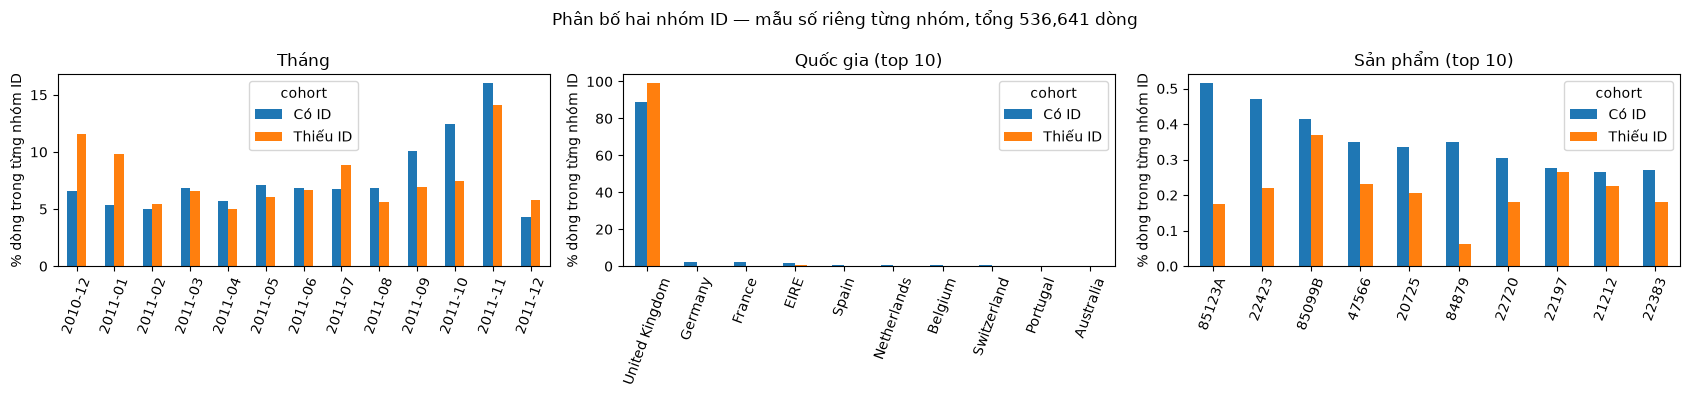

,,hoa_don,dong
id_pattern,ids,,
Toàn có ID,1,22190,401604
Toàn thiếu ID,0,3710,135037


Dòng không có InvoiceNo, không tổng hợp: 0


,rows,missing_ids,ids,priced_rows,signed_value,id_pattern
InvoiceNo,,,,,,


In [2]:
a = df.copy()
a['missing_id'] = missing(a.CustomerID)
a['cohort'] = np.where(a.missing_id,'Thiếu ID','Có ID')
for c in TEXT: a[c+'_norm'] = a[c].str.strip().str.upper()
a['cancel'] = a.InvoiceNo_norm.str.startswith('C', na=False)
a['valid_qty'] = a.Quantity.notna() & np.isfinite(a.Quantity.astype(float))
a['valid_price'] = a.UnitPrice.notna() & np.isfinite(a.UnitPrice)
a['line_value'] = (a.Quantity.astype(float)*a.UnitPrice).where(a.valid_qty & a.valid_price)
a['valid_value'] = a.line_value.notna() & np.isfinite(a.line_value)
a['line_value'] = a.line_value.where(a.valid_value)
a['positive'] = a.valid_value & a.Quantity.gt(0).fillna(False) & a.UnitPrice.gt(0).fillna(False)
cohort_rows=[]
for name,g in a.groupby('cohort'):
    cohort_rows.append({'nhom':name,'dong':len(g),'hoa_don':g.InvoiceNo.nunique(),'huy_pct':100*g.cancel.mean(),'qty_am_pct':100*g.Quantity.lt(0).fillna(False).mean(),'gia_0_pct':100*g.UnitPrice.eq(0).mean(),'gia_am_pct':100*g.UnitPrice.lt(0).mean(),'gia_tri_co_dau':g.loc[g.valid_value,'line_value'].sum(),'gia_tri_dong_duong':g.loc[g.positive,'line_value'].sum()})
cohorts=pd.DataFrame(cohort_rows).set_index('nhom'); display(cohorts)
assert cohorts.dong.sum()==N and int(a.missing_id.sum())+int((~a.missing_id).sum())==N
missing_by_group = pd.DataFrame({name: pd.Series({c:100*missing(g[c]).mean() for c in COLS}) for name,g in a.groupby('cohort')})
display(missing_by_group.rename_axis('cot: ty le thieu %'))
display(a.groupby('cohort')[['Quantity','UnitPrice','line_value']].quantile([.01,.25,.5,.75,.95,.99,.995]).rename_axis(['nhom','phan_vi']))
a['month'] = a.InvoiceDate.dt.to_period('M').astype('string').fillna('Thiếu ngày')
fig,axes=plt.subplots(1,3,figsize=(17,4))
for ax,col,title in zip(axes,['month','Country','StockCode'],['Tháng','Quốc gia (top 10)','Sản phẩm (top 10)']):
    table=pd.crosstab(a[col].fillna('Thiếu'),a.cohort)
    if col!='month': table=table.loc[table.sum(axis=1).nlargest(10).index]
    shares=table.div(a.groupby('cohort').size(),axis=1)*100
    shares.plot.bar(ax=ax); ax.set_title(title); ax.set_ylabel('% dòng trong từng nhóm ID'); ax.set_xlabel(''); ax.tick_params(axis='x',rotation=70)
plt.suptitle(f'Phân bố hai nhóm ID — mẫu số riêng từng nhóm, tổng {N:,} dòng'); plt.tight_layout(); plt.show()
# Không ghép mọi InvoiceNo thiếu thành một hóa đơn.
invoice_source=a.loc[~missing(a.InvoiceNo)].copy()
inv=invoice_source.groupby('InvoiceNo',sort=True).agg(rows=('InvoiceNo','size'),missing_ids=('missing_id','sum'),ids=('CustomerID_norm',lambda s:s.mask(s.eq('')).nunique()),priced_rows=('valid_value','sum'),signed_value=('line_value',lambda s:s.sum(min_count=1)))
inv['id_pattern']=np.select([inv.missing_ids.eq(inv.rows),inv.missing_ids.gt(0)],['Toàn thiếu ID','Hỗn hợp có/thiếu ID'],default='Toàn có ID')
display(inv.groupby(['id_pattern','ids']).agg(hoa_don=('rows','size'),dong=('rows','sum')))
print('Dòng không có InvoiceNo, không tổng hợp:',int(missing(a.InvoiceNo).sum()))
display(inv.loc[inv.id_pattern.eq('Hỗn hợp có/thiếu ID')].head(10))
assert inv.rows.sum()+missing(a.InvoiceNo).sum()==N


## C. Đối chiếu mô tả với tên sản phẩm theo StockCode
Các cờ quan sát độc lập có thể giao nhau. Cờ từ khóa chỉ là **nghi vấn nghiệp vụ**, không phải nhãn thật.

Tên tham chiếu là mô tả chuẩn hóa xuất hiện trên ít nhất **2 hóa đơn khác nhau** có hình thức bán hàng (số lượng và giá dương, không hủy), không thuộc phí/mã chữ đặc biệt. Giữ tất cả tên đạt điều kiện của cùng StockCode, không chỉ tên phổ biến nhất. Đây là bằng chứng từ dữ liệu, không phải danh mục sản phẩm đã xác thực.

- Khớp từ đầy đủ: `STOCK` không bắt `STOCKING`; các biến thể như `DAMAGED`, `DAMAGES` được liệt kê rõ.
- Mô tả trùng tên tham chiếu của **cùng mã**: `keyword_product_name`, không suy ra nghiệp vụ kho từ từ khóa.
- Mô tả khớp từ khóa, khác tên tham chiếu và mã có tham chiếu: cờ `stock_words`/`damage_words`/`loss_words`/`coding_words` là nghi vấn cần đối soát.
- Mô tả khớp từ khóa nhưng thiếu mã hoặc chưa đủ tên tham chiếu: `keyword_unresolved`, chưa ép nhóm.

Tham chiếu toàn kỳ chỉ dùng cho EDA hồi cứu. Không có từ khóa không có nghĩa giao dịch bình thường. Giá 0/số lượng âm là bằng chứng bổ sung, không phải điều kiện để khẳng định nguyên nhân.


In [3]:
# Đọc literal danh sách hiện hành bằng AST, không import/khởi động PySpark.
tree=ast.parse((ROOT/'scripts/pyspark_clean.py').read_text(encoding='utf-8'))
constants={node.targets[0].id:ast.literal_eval(node.value) for node in tree.body if isinstance(node,ast.Assign) and isinstance(node.targets[0],ast.Name) and node.targets[0].id in ['RFM_EXCLUDED_STOCK_CODES','RFM_EXCLUDED_DESCRIPTIONS']}
a['service']=a.StockCode_norm.isin(constants['RFM_EXCLUDED_STOCK_CODES']) | a.Description_norm.isin(constants['RFM_EXCLUDED_DESCRIPTIONS'])
print('Danh sách phí/dịch vụ hiện tại:',constants)
a['special_code']=a.StockCode_norm.str.fullmatch(r'[A-Z ]+',na=False)
patterns={
    'stock_words':r'\b(?:CHECK(?:ED|ING|S)?|ADJUST(?:ED|MENT|MENTS|ING)?|COUNTED|STOCK|HISTORIC|FOUND|TEST(?:ING|ED|S)?)\b',
    'damage_words':r'\b(?:DAMAG(?:E|ED|ES|ING)|DAGAM(?:E|ED)|FAULT(?:Y|S)?|MOULD(?:Y)?|WET|RUST(?:Y)?|SMASH(?:ED)?|CRUSH(?:ED)?|CRACK(?:ED)?|BROKEN|BREAKAGE|UNSALEABLE|THROWN)\b',
    'loss_words':r"\b(?:MISSING|LOST|MIA|NOT RCVD|CAN['’]?T FIND)\b",
    'coding_words':r'\b(?:WRONG(?:LY)?|INCORRECT(?:LY)?|BARCODE|MIXED UP|MARKED|MRKED|CODED)\b',
}
def description_context(frame):
    stock=frame.StockCode_norm.astype('string').str.strip().str.upper()
    desc=frame.Description_norm.astype('string').str.strip().str.upper().str.replace(r'\s+',' ',regex=True)
    valid=stock.notna() & stock.ne('') & desc.notna() & desc.ne('')
    paid=frame.sale_shape & ~frame.service & ~frame.special_code & valid
    observed=pd.DataFrame({'StockCode_norm':stock,'product_name':desc,'InvoiceNo':frame.InvoiceNo})
    reference=(observed.loc[paid].groupby(['StockCode_norm','product_name']).InvoiceNo.nunique().rename('paid_invoices').reset_index())
    reference=reference.loc[reference.paid_invoices.ge(2)].copy()
    pairs=pd.MultiIndex.from_frame(observed[['StockCode_norm','product_name']])
    known=pd.Series(pairs.isin(pd.MultiIndex.from_frame(reference[['StockCode_norm','product_name']])),index=frame.index)
    has_reference=stock.isin(reference.StockCode_norm)
    raw_flags=pd.DataFrame({name:desc.str.contains(pattern,regex=True,na=False) for name,pattern in patterns.items()},index=frame.index)
    result=raw_flags.copy()
    result['keyword_candidate']=raw_flags.any(axis=1)
    result['keyword_product_name']=result.keyword_candidate & known
    result['keyword_unresolved']=result.keyword_candidate & ~has_reference
    for name in patterns: result[name]=raw_flags[name] & has_reference & ~known
    return result,reference

a['zero_negative']=a.UnitPrice.eq(0)&a.Quantity.lt(0).fillna(False)
a['zero_positive']=a.UnitPrice.eq(0)&a.Quantity.gt(0).fillna(False)
a['sale_shape']=~a.cancel & ~missing(a.InvoiceNo) & a.positive
context_flags,product_reference=description_context(a)
for name in context_flags: a[name]=context_flags[name]
display(pd.Series(patterns,name='Khớp từ đầy đủ, sau đối chiếu tên sản phẩm cùng StockCode'))
print('Tên tham chiếu: ít nhất 2 hóa đơn bán có giá khác nhau; không phải danh mục xác thực')
display(product_reference.loc[product_reference.StockCode_norm.eq('85084')])
assert not a.loc[a.StockCode_norm.eq('85084') & a.Description_norm.eq('HOLLY TOP CHRISTMAS STOCKING'),list(patterns)].any().any()
comparison_rows=[]
legacy_patterns={'stock_words':r'CHECK|ADJUST|COUNTED|STOCK|HISTORIC|FOUND|TEST','damage_words':r'DAMAG|DAGAM|FAULT|MOULD|WET|RUST|SMASH|CRUSH|CRACK|BROKEN|BREAKAGE|UNSALEABLE|THROWN','loss_words':r'MISSING|LOST|MIA|NOT RCVD|CAN.T FIND','coding_words':r'WRONG|INCORRECT|BARCODE|MIXED UP|MARKED|MRKED|CODED'}
for name in patterns:
    for cohort,idx in a.groupby('cohort').groups.items():
        g=a.loc[idx]
        comparison_rows.append({'co':name,'nhom':cohort,'khop_chuoi_cu':int(g.Description_norm.str.contains(legacy_patterns[name],regex=True,na=False).sum()),'nghi_van_sau_doi_chieu':int(g[name].sum())})
display(pd.DataFrame(comparison_rows))
print('Kết quả đối chiếu từ khóa (cùng mẫu số nhóm ID):')
display(a.groupby('cohort')[['keyword_candidate','keyword_product_name','keyword_unresolved']].sum())
# Nhiều tên tham chiếu cho một mã: hiển thị mẫu, không join nhân bản dòng giao dịch.
name_lookup=product_reference.groupby('StockCode_norm').product_name.agg(lambda s:' | '.join(sorted(s)[:3]))
for status in ['keyword_product_name','keyword_unresolved',*patterns]:
    print(status,'— tối đa 5 mô tả và tên tham chiếu cùng mã:')
    sample=a.loc[a[status],['StockCode','StockCode_norm','Description','Quantity','UnitPrice','CustomerID']].drop_duplicates(['StockCode_norm','Description']).sort_values(['StockCode_norm','Description']).head(5).copy()
    sample['ten_tham_chieu']=sample.StockCode_norm.map(name_lookup)
    display(sample)
flag_names=['cancel','service','special_code','zero_negative','zero_positive','sale_shape','keyword_product_name','keyword_unresolved',*patterns]
flags=a[flag_names].astype(bool)
display(flags.groupby(a.cohort).sum().T)
display(flags.astype('int64').T @ flags.astype('int64'))
display(a.loc[a.special_code].groupby(['StockCode_norm','cohort']).size().rename('dong').unstack(fill_value=0).sort_index())
for name in patterns:
    print(name,'— ví dụ mô tả (suy luận):')
    display(a.loc[a[name],['Description','Quantity','UnitPrice','CustomerID']].drop_duplicates().head(5))
assert len(a)==N


Danh sách phí/dịch vụ hiện tại: {'RFM_EXCLUDED_STOCK_CODES': ('POST', 'M', 'DOT', 'BANK CHARGES', 'C2', 'PADS'), 'RFM_EXCLUDED_DESCRIPTIONS': ('PACKING CHARGE', 'NEXT DAY CARRIAGE')}


stock_words     \b(?:CHECK(?:ED|ING|S)?|ADJUST(?:ED|MENT|MENTS...
damage_words    \b(?:DAMAG(?:E|ED|ES|ING)|DAGAM(?:E|ED)|FAULT(...
loss_words       \b(?:MISSING|LOST|MIA|NOT RCVD|CAN['’]?T FIND)\b
coding_words    \b(?:WRONG(?:LY)?|INCORRECT(?:LY)?|BARCODE|MIX...
Name: Khớp từ đầy đủ, sau đối chiếu tên sản phẩm cùng StockCode, dtype: str

Tên tham chiếu: ít nhất 2 hóa đơn bán có giá khác nhau; không phải danh mục xác thực


,StockCode_norm,product_name,paid_invoices
3499,85084,HOLLY TOP CHRISTMAS STOCKING,7


,co,nhom,khop_chuoi_cu,nghi_van_sau_doi_chieu
0,stock_words,Có ID,861,0
1,stock_words,Thiếu ID,551,246
2,damage_words,Có ID,4852,1
3,damage_words,Thiếu ID,1436,163
4,loss_words,Có ID,104,0
5,loss_words,Thiếu ID,129,20
6,coding_words,Có ID,0,0
7,coding_words,Thiếu ID,31,31


...

,Description,Quantity,UnitPrice,CustomerID
15087,incorrectly made-thrown away.,-64,0.0,<NA>
16762,damaged stock,-1100,0.0,<NA>
18478,Damaged,-1440,0.0,<NA>
18572,wet damaged,-96,0.0,<NA>
23438,damages,-59,0.0,<NA>


loss_words — ví dụ mô tả (suy luận):


,Description,Quantity,UnitPrice,CustomerID
59178,?lost,-232,0.0,<NA>
80025,?? missing,-170,0.0,<NA>
83458,lost in space,-98,0.0,<NA>
123635,???lost,-550,0.0,<NA>
170506,missing,-338,0.0,<NA>


coding_words — ví dụ mô tả (suy luận):


,Description,Quantity,UnitPrice,CustomerID
15087,incorrectly made-thrown away.,-64,0.0,<NA>
16608,wrongly sold as sets,-600,0.0,<NA>
35118,wrongly coded 23343,1000,0.0,<NA>
36021,wrongly marked carton 22804,-256,0.0,<NA>
59663,wrong barcode (22467),-178,0.0,<NA>


In [4]:
def test_description_context():
    probe=pd.DataFrame({
        'StockCode_norm':['85084','85084','85084','A','A','A','B','C','A',None],
        'Description_norm':['HOLLY TOP CHRISTMAS STOCKING','HOLLY TOP CHRISTMAS STOCKING','stock adjustment','CHECK DESIGN BAG','CHECK DESIGN BAG','damaged','damaged','CHECK DESIGN BAG',None,'damaged'],
        'InvoiceNo':['1','2','3','4','5','6','7','8','9','10'],
        'sale_shape':[True,True,False,True,True,False,False,False,False,False],
        'service':[False]*10,'special_code':[False]*10,
    })
    probe.Description_norm=probe.Description_norm.astype('string').str.upper()
    result,reference=description_context(probe)
    assert not result.loc[0,'stock_words']  # STOCK must not match STOCKING.
    assert result.loc[3,'keyword_product_name'] and not result.loc[3,'stock_words']
    assert result.loc[2,'stock_words'] and result.loc[5,'damage_words']
    assert result.loc[6,'keyword_unresolved'] and not result.loc[6,'damage_words']
    assert result.loc[7,'keyword_unresolved']  # Same name under another code is not evidence.
    assert not result.loc[8,'keyword_candidate']
    assert result.loc[9,'keyword_unresolved']
    assert len(result)==len(probe) and result.index.equals(probe.index)
    # Repeated lines within one invoice do not establish a recurring product name.
    repeated=probe.iloc[[3,3]].reset_index(drop=True)
    r,_=description_context(repeated)
    assert r.keyword_unresolved.all()

test_description_context()
print('PASS: StockCode/name context, word boundaries, missing reference and single-invoice evidence')


PASS: StockCode/name context, word boundaries, missing reference and single-invoice evidence


## D. Điều kiện áp dụng từng phép phân tích
“Hợp lệ” ở đây nghĩa là có giá trị số hữu hạn, không có nghĩa giá trị dương. Số âm vẫn hữu ích để kiểm tra hoàn/hủy. Eligibility thống kê ở phần E còn yêu cầu đúng nhóm nghiệp vụ và đủ mẫu. Dòng không đánh giá được không bị coi là bình thường.

In [5]:
eligible=pd.DataFrame({'quantity_product':~missing(a.StockCode)&a.valid_qty,'price_product':~missing(a.StockCode)&a.valid_price,'line_value':a.valid_value,'invoice':~missing(a.InvoiceNo),'time':a.InvoiceDate.notna(),'customer_history':~a.missing_id})
eligibility_rows=[]
for group,idx in a.groupby('cohort').groups.items():
    for rule in eligible:
        yes=int(eligible.loc[idx,rule].sum()); total=len(idx)
        eligibility_rows.append({'nhom':group,'phan_tich':rule,'du_dieu_kien':yes,'khong_du':total-yes,'mau_so':total,'du_pct':100*yes/total})
eligibility=pd.DataFrame(eligibility_rows); display(eligibility)
assert (eligibility.du_dieu_kien+eligibility.khong_du==eligibility.mau_so).all()
inv['missing_value_rows']=inv.rows-inv.priced_rows
print('Hóa đơn thiếu thành phần tính tiền:',int(inv.missing_value_rows.gt(0).sum()))
display(inv.loc[inv.missing_value_rows.gt(0)].head(10))


,nhom,phan_tich,du_dieu_kien,khong_du,mau_so,du_pct
0,Có ID,quantity_product,401604,0,401604,100.0
1,Có ID,price_product,401604,0,401604,100.0
2,Có ID,line_value,401604,0,401604,100.0
3,Có ID,invoice,401604,0,401604,100.0
4,Có ID,time,401604,0,401604,100.0
5,Có ID,customer_history,401604,0,401604,100.0
6,Thiếu ID,quantity_product,135037,0,135037,100.0
7,Thiếu ID,price_product,135037,0,135037,100.0
8,Thiếu ID,line_value,135037,0,135037,100.0
9,Thiếu ID,invoice,135037,0,135037,100.0


Hóa đơn thiếu thành phần tính tiền: 0


,rows,missing_ids,ids,priced_rows,signed_value,id_pattern,missing_value_rows
InvoiceNo,,,,,,,


## E. Quy tắc ứng viên và độ nhạy
Mỗi quy tắc có mask áp dụng riêng. Tỷ lệ đánh dấu báo cả trên toàn nhóm ID và trên số dòng đủ điều kiện. IQR chỉ dùng nhóm có hình thức bán hàng, không thuộc danh sách phí hoặc mã chữ đặc biệt, theo từng StockCode chuẩn hóa. Cả hai nhóm ID cùng tham gia tham chiếu. Ngưỡng toàn kỳ là **hồi cứu**, không phải đánh giá detector hằng ngày.

In [6]:
def upper_iqr(values, count, q1, q3, factor):
    spread=q3-q1
    assessed=(values.notna() & np.isfinite(values) & count.ge(30) & spread.gt(0) & np.isfinite(q1) & np.isfinite(q3)).fillna(False)
    flagged=(assessed & values.gt(q3+factor*spread)).fillna(False)
    return assessed,flagged


In [7]:
import pandas as pd
import numpy as np

def test_iqr_contract():
    values = pd.Series([5., 6., 7., np.nan])
    assessed, flagged = upper_iqr(values, pd.Series([30,30,30,30]), pd.Series([1.,1.,1.,1.]), pd.Series([3.,3.,3.,3.]), 1.5)
    assert assessed.tolist() == [True, True, True, False]
    assert flagged.tolist() == [False, False, True, False]
    a, f = upper_iqr(pd.Series([99.,99.]), pd.Series([29,30]), pd.Series([1.,3.]), pd.Series([3.,3.]), 1.5)
    assert not a.any() and not f.any()

test_iqr_contract()


Quantity — phân vị sản phẩm (10 nhóm nhiều dòng nhất)


,n,q1,q3,p95,p99,p995
StockCode_norm,,,,,,
85123A,2320,3.0,12.0,32.0,150.0,273.82
85099B,2109,3.0,11.0,100.0,200.0,300.0
22423,2007,1.0,6.0,24.7,64.0,119.76
47566,1699,3.0,8.0,50.0,100.0,150.0
20725,1582,2.0,10.0,40.0,100.0,100.0
84879,1476,8.0,24.0,66.0,160.0,160.0
22197,1418,4.0,24.0,100.0,600.0,1000.0
22720,1392,2.0,3.0,12.0,64.0,96.0
21212,1352,2.0,24.0,120.0,240.0,480.0


UnitPrice — phân vị sản phẩm (10 nhóm nhiều dòng nhất)


,n,q1,q3,p95,p99,p995
StockCode_norm,,,,,,
85123A,2320,2.95,2.95,5.79,6.630,6.63
85099B,2109,1.95,2.08,4.13,4.210,4.21
22423,2007,12.75,12.75,24.96,25.490,25.49
47566,1699,4.95,4.95,10.79,10.790,10.79
20725,1582,1.65,1.65,4.96,4.960,5.06
84879,1476,1.69,1.69,1.69,3.120,3.19
22197,1418,0.85,0.85,1.66,2.460,2.46
22720,1392,4.95,4.95,10.79,11.020,11.02
21212,1352,0.55,0.55,2.08,2.080,2.13


line_value — phân vị sản phẩm (10 nhóm nhiều dòng nhất)


,n,q1,q3,p95,p99,p995
StockCode_norm,,,,,,
85123A,2320,8.85,35.40,88.665,408.0000,736.32100
85099B,2109,8.26,33.04,179.000,389.8576,537.00000
22423,2007,24.96,76.50,350.400,788.4000,1314.00000
47566,1699,14.85,39.60,207.500,622.5000,728.64870
20725,1582,4.95,16.50,115.429,153.7600,218.51270
84879,1476,13.52,40.56,111.540,232.0000,232.00000
22197,1418,4.89,21.19,72.000,432.0000,851.76000
22720,1392,10.79,19.80,68.000,260.1700,411.02400
21212,1352,1.65,13.20,50.400,153.4746,243.46095


,bien,dong_nen,nhom_san_pham,nhom_it_mau,nhom_du_mau_IQR0,dong_it_mau,dong_du_mau_IQR0
0,Quantity,522451,3799,1245,109,13489,13603
1,UnitPrice,522451,3799,1245,1245,13489,281189
2,line_value,522451,3799,1245,76,13489,11055


,quy_tac,nhom,mau_so,du_dieu_kien,danh_dau,pct_toan_nhom,pct_du_dieu_kien
0,C_quantity_nonnegative,Có ID,401604,401604,0,0.000000,0.000000
1,C_quantity_nonnegative,Thiếu ID,135037,135037,0,0.000000,0.000000
2,negative_quantity_nonC,Có ID,401604,401604,0,0.000000,0.000000
3,negative_quantity_nonC,Thiếu ID,135037,135037,1336,0.989358,0.989358
4,negative_price,Có ID,401604,401604,0,0.000000,0.000000
5,negative_price,Thiếu ID,135037,135037,2,0.001481,0.001481
6,zero_in_paid_invoice,Có ID,401604,401604,33,0.008217,0.008217
7,zero_in_paid_invoice,Thiếu ID,135037,135037,362,0.268075,0.268075
8,all_zero_invoice,Có ID,401604,401604,7,0.001743,0.001743
9,all_zero_invoice,Thiếu ID,135037,135037,2108,1.561054,1.561054


Quantity : 1.5 = 38048 ; 3 = 24869 ; chỉ mức 1.5 = 13179
UnitPrice : 1.5 = 9202 ; 3 = 7588 ; chỉ mức 1.5 = 1614
line_value : 1.5 = 42381 ; 3 = 26639 ; chỉ mức 1.5 = 15742


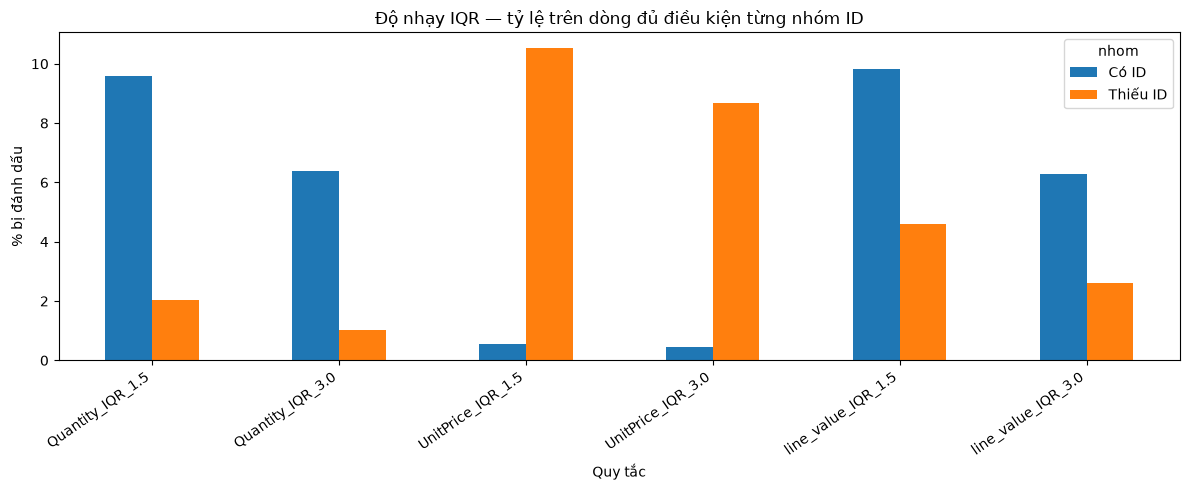

In [8]:
invoice_groups=invoice_source.groupby('InvoiceNo')
paid=invoice_groups.UnitPrice.apply(lambda s:s.gt(0).any())
invoice_prices_valid=invoice_groups.valid_price.all()
all_zero=invoice_groups.UnitPrice.apply(lambda s:s.notna().all() and s.eq(0).all())
known_invoice=~missing(a.InvoiceNo)
rules={}
def add_rule(name, applies, condition):
    applies=applies.fillna(False).astype(bool)
    rules[name]=(applies,(applies & condition.fillna(False)).astype(bool))
add_rule('C_quantity_nonnegative',known_invoice&a.valid_qty,a.cancel&a.Quantity.ge(0))
add_rule('negative_quantity_nonC',known_invoice&a.valid_qty,~a.cancel&a.Quantity.lt(0))
add_rule('negative_price',a.valid_price,a.UnitPrice.lt(0))
add_rule('zero_in_paid_invoice',known_invoice&a.valid_price,a.UnitPrice.eq(0)&a.InvoiceNo.map(paid).fillna(False))
add_rule('all_zero_invoice',known_invoice&a.InvoiceNo.map(invoice_prices_valid).fillna(False),a.InvoiceNo.map(all_zero).fillna(False))
add_rule('multiple_customer_ids',known_invoice,a.InvoiceNo.map(inv.ids).gt(1))
BUSINESS=list(rules)
base=a.sale_shape & ~a.service & ~a.special_code & ~missing(a.StockCode)
stat_tables={}; coverage=[]
for metric in ['Quantity','UnitPrice','line_value']:
    values=a[metric].astype(float)
    valid_base=base & values.notna() & np.isfinite(values)
    grouped=a.loc[valid_base].groupby('StockCode_norm')[metric]
    stats=grouped.agg(n='size').join(grouped.quantile([.25,.75,.95,.99,.995]).unstack().rename(columns={.25:'q1',.75:'q3',.95:'p95',.99:'p99',.995:'p995'}))
    stat_tables[metric]=stats
    mapped=stats.reindex(a.StockCode_norm).set_axis(a.index)
    assert len(mapped)==N
    for factor in [1.5,3.0]:
        assessed,flagged=upper_iqr(values,mapped.n,mapped.q1,mapped.q3,factor)
        add_rule(f'{metric}_IQR_{factor}',valid_base & assessed,flagged)
    coverage.append({'bien':metric,'dong_nen':int(valid_base.sum()),'nhom_san_pham':len(stats),'nhom_it_mau':int(stats.n.lt(30).sum()),'nhom_du_mau_IQR0':int((stats.n.ge(30)&stats.q1.eq(stats.q3)).sum()),'dong_it_mau':int((valid_base & mapped.n.lt(30)).sum()),'dong_du_mau_IQR0':int((valid_base & mapped.n.ge(30)&mapped.q1.eq(mapped.q3)).sum())})
    print(metric,'— phân vị sản phẩm (10 nhóm nhiều dòng nhất)'); display(stats.sort_values('n',ascending=False).head(10))
display(pd.DataFrame(coverage))
rule_rows=[]
for rule,(applies,flagged) in rules.items():
    for group,idx in a.groupby('cohort').groups.items():
        total=len(idx); n_apply=int(applies.loc[idx].sum()); n_flag=int(flagged.loc[idx].sum())
        rule_rows.append({'quy_tac':rule,'nhom':group,'mau_so':total,'du_dieu_kien':n_apply,'danh_dau':n_flag,'pct_toan_nhom':100*n_flag/total,'pct_du_dieu_kien':100*n_flag/n_apply if n_apply else np.nan})
rule_summary=pd.DataFrame(rule_rows); display(rule_summary)
for metric in stat_tables:
    loose=rules[f'{metric}_IQR_1.5'][1]; strict=rules[f'{metric}_IQR_3.0'][1]
    assert not (strict & ~loose).any()
    print(metric,': 1.5 =',int(loose.sum()),'; 3 =',int(strict.sum()),'; chỉ mức 1.5 =',int((loose & ~strict).sum()))
fig,ax=plt.subplots(figsize=(12,5))
rule_summary.loc[rule_summary.quy_tac.str.contains('IQR')].pivot(index='quy_tac',columns='nhom',values='pct_du_dieu_kien').plot.bar(ax=ax)
ax.set_title('Độ nhạy IQR — tỷ lệ trên dòng đủ điều kiện từng nhóm ID'); ax.set_ylabel('% bị đánh dấu'); ax.set_xlabel('Quy tắc'); plt.xticks(rotation=35,ha='right'); plt.tight_layout(); plt.show()
assert sum(int(v[0][a.missing_id].sum()) for k,v in rules.items() if 'IQR' in k)>0
assert len(a)==N


## F. Ví dụ và đối soát ngữ cảnh
Mỗi quy tắc hiển thị tối đa 10 dòng. Thứ tự: độ lớn giảm dần, ngày, hóa đơn, sản phẩm; thêm cột gốc để phá hòa ổn định. Bảng giá trị hóa đơn không áp ngưỡng chung, không được hiểu là bảng gian lận.

In [9]:
def examples(mask,metric='line_value',limit=10):
    selected=a.loc[mask].copy()
    selected['_magnitude']=selected[metric].astype(float).abs()
    return selected.sort_values(['_magnitude','InvoiceDate','InvoiceNo','StockCode','Description','CustomerID','Country','Quantity','UnitPrice'],ascending=[False,True,True,True,True,True,True,True,True],kind='stable',na_position='last').head(limit)
for rule,(_,flagged) in rules.items():
    metric=rule.split('_IQR')[0] if '_IQR' in rule else 'line_value'
    print(rule,'—',int(flagged.sum()),'dòng; tối đa 10 ví dụ:')
    display(examples(flagged,metric)[COLS+['line_value','cohort']])
print('Hóa đơn có giá trị có dấu lớn nhất theo trị tuyệt đối (có thể gồm phí/bút toán):')
display(inv.assign(abs_value=inv.signed_value.abs()).sort_values(['abs_value'],ascending=False).head(10))
# Một trường hợp đại diện cho từng chủ đề; không in toàn bộ hóa đơn dài.
case_masks={'Điều chỉnh tiềm năng':a.zero_negative & ~a.cancel,'Giá âm':rules['negative_price'][1],'Giá 0 trong đơn trả tiền':rules['zero_in_paid_invoice'][1],'Số lượng cực đoan thiếu ID':rules['Quantity_IQR_3.0'][1]&a.missing_id,'Số lượng cực đoan có ID':rules['Quantity_IQR_3.0'][1]&~a.missing_id}
case_results=[]
for label,mask in case_masks.items():
    selected=examples(mask,'Quantity',1)
    if selected.empty: continue
    row=selected.iloc[0]
    same_invoice=a.InvoiceNo.eq(row.InvoiceNo).fillna(False) if pd.notna(row.InvoiceNo) else pd.Series(False,index=a.index)
    product=a.StockCode_norm.eq(row.StockCode_norm).fillna(False)
    customer=a.CustomerID_norm.eq(row.CustomerID_norm).fillna(False) if not row.missing_id else pd.Series(False,index=a.index)
    reversal=product & a.Quantity.eq(-row.Quantity).fillna(False) & a.UnitPrice.eq(row.UnitPrice).fillna(False) & a.cancel.ne(row.cancel)
    if not row.missing_id: reversal &= customer
    print('TRƯỜNG HỢP:',label)
    display(selected[COLS+['line_value']])
    print('Cùng hóa đơn:',int(same_invoice.sum()),'dòng — hiển thị tối đa 5'); display(examples(same_invoice,limit=5)[COLS])
    print('Cùng sản phẩm:'); display(a.loc[product,['Quantity','UnitPrice','line_value']].describe(percentiles=[.5,.95,.99]))
    print('Lịch sử khách hàng:', 'không đánh giá: thiếu ID' if row.missing_id else f'{int(customer.sum())} dòng, {a.loc[customer,"InvoiceNo"].nunique()} hóa đơn')
    if not row.missing_id: display(examples(customer,limit=5)[COLS])
    print('Ứng viên hoàn/hủy cùng sản phẩm, giá, lượng đối dấu:',int(reversal.sum()),'— chưa chứng minh liên kết'); display(examples(reversal,limit=5)[COLS])
    if label=='Điều chỉnh tiềm năng' and any(bool(row[k]) for k in patterns):
        finding='Có giải thích nghiệp vụ (suy luận từ mô tả), chưa xác nhận'
    elif label.startswith('Số lượng cực đoan') and not reversal.any():
        finding='Còn đáng nghi: vượt IQR, chưa có bằng chứng giải thích'
    else: finding='Chưa đủ bằng chứng để kết luận sai hay bình thường'
    case_results.append({'chu_de':label,'hoa_don':row.InvoiceNo,'san_pham':row.StockCode,'nhan_dinh':finding,'ung_vien_hoan':int(reversal.sum())})
display(pd.DataFrame(case_results))


C_quantity_nonnegative — 0 dòng; tối đa 10 ví dụ:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,line_value,cohort


negative_quantity_nonC — 1336 dòng; tối đa 10 ví dụ:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,line_value,cohort
229201,536589,21777,<NA>,-10,2010-12-01 16:50:00,0.0,<NA>,United Kingdom,-0.0,Thiếu ID
315314,536764,84952C,<NA>,-38,2010-12-02 14:42:00,0.0,<NA>,United Kingdom,-0.0,Thiếu ID
528684,536996,22712,<NA>,-20,2010-12-03 15:30:00,0.0,<NA>,United Kingdom,-0.0,Thiếu ID
13987,536997,22028,<NA>,-20,2010-12-03 15:30:00,0.0,<NA>,United Kingdom,-0.0,Thiếu ID
315211,536998,85067,<NA>,-6,2010-12-03 15:30:00,0.0,<NA>,United Kingdom,-0.0,Thiếu ID
185674,537000,21414,<NA>,-22,2010-12-03 15:32:00,0.0,<NA>,United Kingdom,-0.0,Thiếu ID
228421,537001,21653,<NA>,-6,2010-12-03 15:33:00,0.0,<NA>,United Kingdom,-0.0,Thiếu ID
486598,537003,85126,<NA>,-2,2010-12-03 15:33:00,0.0,<NA>,United Kingdom,-0.0,Thiếu ID
100101,537004,21814,<NA>,-30,2010-12-03 15:34:00,0.0,<NA>,United Kingdom,-0.0,Thiếu ID
357809,537005,21692,<NA>,-70,2010-12-03 15:35:00,0.0,<NA>,United Kingdom,-0.0,Thiếu ID


negative_price — 2 dòng; tối đa 10 ví dụ:


...

Lịch sử khách hàng: 2 dòng, 2 hóa đơn


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
432045,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,12346,United Kingdom
88940,C541433,23166,MEDIUM CERAMIC TOP STORAGE JAR,-74215,2011-01-18 10:17:00,1.04,12346,United Kingdom


Ứng viên hoàn/hủy cùng sản phẩm, giá, lượng đối dấu: 1 — chưa chứng minh liên kết


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
88940,C541433,23166,MEDIUM CERAMIC TOP STORAGE JAR,-74215,2011-01-18 10:17:00,1.04,12346,United Kingdom


,chu_de,hoa_don,san_pham,nhan_dinh,ung_vien_hoan
0,Điều chỉnh tiềm năng,556690,23005,"Có giải thích nghiệp vụ (suy luận từ mô tả), c...",0
1,Giá âm,A563186,B,Chưa đủ bằng chứng để kết luận sai hay bình th...,0
2,Giá 0 trong đơn trả tiền,568567,46000S,Chưa đủ bằng chứng để kết luận sai hay bình th...,0
3,Số lượng cực đoan thiếu ID,574941,22197,"Còn đáng nghi: vượt IQR, chưa có bằng chứng gi...",0
4,Số lượng cực đoan có ID,541431,23166,Chưa đủ bằng chứng để kết luận sai hay bình th...,1


## G. Kết luận có điều kiện và đề xuất detector
Các bảng dưới được tính từ lần chạy này. Quy tắc nghiệp vụ ưu tiên đối soát; vượt IQR chỉ là khác biệt thống kê. Không có nhãn xác thực nên không báo precision/recall. Không suy rộng nhóm điều chỉnh nhỏ thành toàn bộ nhóm thiếu ID.

In [10]:
missing_total=int(a.missing_id.sum())
composition=flags.loc[a.missing_id].sum().rename('dong').to_frame()
composition['pct_nhom_thieu_ID']=100*composition.dong/missing_total
print('Thành phần nhóm thiếu ID — các cờ giao nhau:'); display(composition)
display(eligibility.loc[eligibility.nhom.eq('Thiếu ID')])
assessed_any=pd.concat([v[0] for k,v in rules.items() if 'IQR' in k],axis=1).any(axis=1)
flagged_any=pd.concat([v[1] for k,v in rules.items() if 'IQR_3.0' in k],axis=1).any(axis=1)
display(Markdown(f"""**Kết quả lần chạy:** Parquet có **{N:,}** dòng; **{missing_total:,} ({100*missing_total/N:.2f}%)** thiếu CustomerID. Trong nhóm thiếu ID, **{int((a.missing_id & assessed_any).sum()):,}** dòng đủ điều kiện ít nhất một phép IQR; **{int((a.missing_id & flagged_any).sum()):,}** dòng vượt ít nhất một ngưỡng mức 3. Đây là số dòng hợp, không cộng lặp giữa ba biến.

CSV loại trùng và Parquet có **{len(mismatch):,} tổ hợp dòng khác nhau** sau đồng nhất kiểu. {'Có thể đối chiếu cùng nội dung.' if mismatch.empty else 'Không đồng nhất nội dung: các kết luận chính chỉ áp dụng cho Parquet đang đọc; cần đối soát parser/encoding/phiên bản trước khi dùng số liệu CSV thay thế.'}

**Không nên bỏ toàn bộ nhóm thiếu ID.** Giữ để phân tích dòng/hóa đơn/sản phẩm nếu đủ trường; chỉ không áp dụng lịch sử khách hàng. Các cờ mô tả là giả thuyết, cần đối soát nghiệp vụ."""))
recommendations=[]
for rule in rules:
    statistical='IQR' in rule
    recommendations.append({'quy_tac':rule,'ap_dung':'Bán hàng sản phẩm, hữu hạn, n>=30, IQR>0' if statistical else {'C_quantity_nonnegative':'Có InvoiceNo và Quantity hữu hạn','negative_quantity_nonC':'Có InvoiceNo và Quantity hữu hạn','negative_price':'UnitPrice hữu hạn','zero_in_paid_invoice':'Có InvoiceNo và UnitPrice; cùng đơn có giá dương','all_zero_invoice':'Mọi dòng của hóa đơn có giá 0, không thiếu giá','multiple_customer_ids':'Có InvoiceNo; đếm ID chuẩn hóa không rỗng'}[rule], 'dong_danh_dau':int(rules[rule][1].sum()),'de_xuat':'Nghiên cứu thêm, so sánh độ nhạy và baseline quá khứ' if statistical else 'Dùng làm cờ cần đối soát, không tự loại dòng','gioi_han':'Tham chiếu toàn kỳ, mùa vụ/giá bậc thang; chưa có nhãn' if statistical else 'Có thể là nghiệp vụ hợp lệ; xem ví dụ phần F'})
display(pd.DataFrame(recommendations))
print('Tỷ lệ theo nhóm và điều kiện áp dụng:'); display(rule_summary)


Thành phần nhóm thiếu ID — các cờ giao nhau:


,dong,pct_nhom_thieu_ID
cancel,379,0.280664
service,896,0.663522
special_code,1009,0.747203
zero_negative,1336,0.989358
zero_positive,1134,0.839770
sale_shape,132186,97.888727
keyword_product_name,293,0.216978
keyword_unresolved,28,0.020735
stock_words,246,0.182172
damage_words,163,0.120708


,nhom,phan_tich,du_dieu_kien,khong_du,mau_so,du_pct
6,Thiếu ID,quantity_product,135037,0,135037,100.0
7,Thiếu ID,price_product,135037,0,135037,100.0
8,Thiếu ID,line_value,135037,0,135037,100.0
9,Thiếu ID,invoice,135037,0,135037,100.0
10,Thiếu ID,time,135037,0,135037,100.0
11,Thiếu ID,customer_history,0,135037,135037,0.0


**Kết quả lần chạy:** Parquet có **536,641** dòng; **135,037 (25.16%)** thiếu CustomerID. Trong nhóm thiếu ID, **126,009** dòng đủ điều kiện ít nhất một phép IQR; **10,102** dòng vượt ít nhất một ngưỡng mức 3. Đây là số dòng hợp, không cộng lặp giữa ba biến.

CSV loại trùng và Parquet có **2,540 tổ hợp dòng khác nhau** sau đồng nhất kiểu. Không đồng nhất nội dung: các kết luận chính chỉ áp dụng cho Parquet đang đọc; cần đối soát parser/encoding/phiên bản trước khi dùng số liệu CSV thay thế.

**Không nên bỏ toàn bộ nhóm thiếu ID.** Giữ để phân tích dòng/hóa đơn/sản phẩm nếu đủ trường; chỉ không áp dụng lịch sử khách hàng. Các cờ mô tả là giả thuyết, cần đối soát nghiệp vụ.

,quy_tac,ap_dung,dong_danh_dau,de_xuat,gioi_han
0,C_quantity_nonnegative,Có InvoiceNo và Quantity hữu hạn,0,"Dùng làm cờ cần đối soát, không tự loại dòng",Có thể là nghiệp vụ hợp lệ; xem ví dụ phần F
1,negative_quantity_nonC,Có InvoiceNo và Quantity hữu hạn,1336,"Dùng làm cờ cần đối soát, không tự loại dòng",Có thể là nghiệp vụ hợp lệ; xem ví dụ phần F
2,negative_price,UnitPrice hữu hạn,2,"Dùng làm cờ cần đối soát, không tự loại dòng",Có thể là nghiệp vụ hợp lệ; xem ví dụ phần F
3,zero_in_paid_invoice,Có InvoiceNo và UnitPrice; cùng đơn có giá dương,395,"Dùng làm cờ cần đối soát, không tự loại dòng",Có thể là nghiệp vụ hợp lệ; xem ví dụ phần F
4,all_zero_invoice,"Mọi dòng của hóa đơn có giá 0, không thiếu giá",2115,"Dùng làm cờ cần đối soát, không tự loại dòng",Có thể là nghiệp vụ hợp lệ; xem ví dụ phần F
5,multiple_customer_ids,Có InvoiceNo; đếm ID chuẩn hóa không rỗng,0,"Dùng làm cờ cần đối soát, không tự loại dòng",Có thể là nghiệp vụ hợp lệ; xem ví dụ phần F
6,Quantity_IQR_1.5,"Bán hàng sản phẩm, hữu hạn, n>=30, IQR>0",38048,"Nghiên cứu thêm, so sánh độ nhạy và baseline q...","Tham chiếu toàn kỳ, mùa vụ/giá bậc thang; chưa..."
7,Quantity_IQR_3.0,"Bán hàng sản phẩm, hữu hạn, n>=30, IQR>0",24869,"Nghiên cứu thêm, so sánh độ nhạy và baseline q...","Tham chiếu toàn kỳ, mùa vụ/giá bậc thang; chưa..."
8,UnitPrice_IQR_1.5,"Bán hàng sản phẩm, hữu hạn, n>=30, IQR>0",9202,"Nghiên cứu thêm, so sánh độ nhạy và baseline q...","Tham chiếu toàn kỳ, mùa vụ/giá bậc thang; chưa..."
9,UnitPrice_IQR_3.0,"Bán hàng sản phẩm, hữu hạn, n>=30, IQR>0",7588,"Nghiên cứu thêm, so sánh độ nhạy và baseline q...","Tham chiếu toàn kỳ, mùa vụ/giá bậc thang; chưa..."


Tỷ lệ theo nhóm và điều kiện áp dụng:


,quy_tac,nhom,mau_so,du_dieu_kien,danh_dau,pct_toan_nhom,pct_du_dieu_kien
0,C_quantity_nonnegative,Có ID,401604,401604,0,0.000000,0.000000
1,C_quantity_nonnegative,Thiếu ID,135037,135037,0,0.000000,0.000000
2,negative_quantity_nonC,Có ID,401604,401604,0,0.000000,0.000000
3,negative_quantity_nonC,Thiếu ID,135037,135037,1336,0.989358,0.989358
4,negative_price,Có ID,401604,401604,0,0.000000,0.000000
5,negative_price,Thiếu ID,135037,135037,2,0.001481,0.001481
6,zero_in_paid_invoice,Có ID,401604,401604,33,0.008217,0.008217
7,zero_in_paid_invoice,Thiếu ID,135037,135037,362,0.268075,0.268075
8,all_zero_invoice,Có ID,401604,401604,7,0.001743,0.001743
9,all_zero_invoice,Thiếu ID,135037,135037,2108,1.561054,1.561054


### Đề xuất đầu ra tương lai — chưa phải hợp đồng của job
Giữ tám cột gốc và bổ sung `data_quality_flags`, `anomaly_flags`, cùng thông tin `checks_applied` / `checks_not_applied` và lý do. Khi có cờ bất thường: `flagged`; không có cờ và ít nhất một phép kiểm tra đã áp dụng: `not_flagged`; không phép nào áp dụng: `not_assessable`. Trạng thái tổng không thay thế trạng thái từng phép kiểm tra.

- **Nên dùng:** cờ thiếu dữ liệu và quy tắc nghiệp vụ minh bạch để phân luồng đối soát; giữ các giao dịch thiếu ID đủ trường.
- **Cần nghiên cứu tiếp:** lựa chọn ngưỡng IQR sau xem ví dụ, tham chiếu chỉ từ quá khứ, nhóm phí/hoàn/điều chỉnh riêng và xử lý sản phẩm ít mẫu.
- **Không nên dùng:** “thiếu CustomerID = bất thường”, điền mọi ID thiếu thành một khách hàng, tự loại dòng bị cờ, hay dùng ngưỡng giá chung cho mọi sản phẩm.
- Danh sách phí hiện hành được tái sử dụng để nhất quán kỹ thuật, không khẳng định mọi mã trong đó có cùng bản chất nghiệp vụ. Không đủ căn cứ suy ra tất cả dòng thiếu ID là khách vãng lai.

## Kiểm chứng cuối cùng
Assertions xác nhận cân bằng cohort, bảo toàn số dòng/cột gốc, ngưỡng và dữ liệu đầu vào không đổi. Notebook không xuất dataset và không sửa cleaning/RFM/Airflow.

### Giới hạn diễn giải từ dữ liệu thực tế
- Kiểm tra đối chiếu ở phần A tách khác biệt Description khỏi bảy cột còn lại. Ví dụ chứa dấu ngoặc kép/ngoặc kép lặp gợi ý khác biệt cách đọc CSV; đây là bằng chứng cần kiểm tra parser, không sửa dữ liệu trong notebook.
- EDA tổng quan cũ bỏ Description thiếu trước khi phân tích số lượng âm/giá 0. Notebook này giữ các dòng đó, vì vậy số liệu các nhóm này có thể lớn hơn; phải dùng cùng cohort trước khi so sánh.
- Chênh lệch tỷ lệ vượt ngưỡng đơn giá giữa hai nhóm ID có thể phản ánh cơ chế giá hoặc kênh bán, chưa phải bằng chứng gian lận hay ID thiếu gây bất thường. Ngưỡng theo sản phẩm vẫn chưa kiểm soát thời gian, số lượng mua và kênh bán.


In [11]:
# Kiểm tra eligibility với dữ liệu nhỏ, độc lập với tỷ lệ thực tế.
probe=pd.DataFrame({'CustomerID':[None,'1'],'StockCode':['A','A'],'Quantity':[7.,np.nan]})
pa_mask,pf_mask=upper_iqr(probe.Quantity,pd.Series([30,30]),pd.Series([1.,1.]),pd.Series([3.,3.]),1.5)
prices_probe=pd.Series([0.,np.nan])
assert not (prices_probe.notna() & np.isfinite(prices_probe)).all()
assert probe.CustomerID.isna()[0] and pa_mask[0] and pf_mask[0]
assert not pa_mask[1] and not pf_mask[1]
assert not (eligible.customer_history & a.missing_id).any()
assert cohorts.dong.sum()==N
assert int(a.CustomerID.isna().sum())==int(quality.loc['CustomerID','null'])
pd.testing.assert_frame_equal(a[COLS],df)
after=fingerprints()
pd.testing.assert_frame_equal(before,after)
print('PASS: IQR boundaries, eligibility, cohorts, row preservation, original columns and all input SHA-256 unchanged.')


PASS: IQR boundaries, eligibility, cohorts, row preservation, original columns and all input SHA-256 unchanged.
